In [71]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score

MISLABELS_CSV = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
RC_XLSX       = Path("/home/student/lisa_ma/evaluation/gt_mislabels_complete.xlsx")
MAX_SCORE     = 8

scores_df = pd.read_csv(MISLABELS_CSV, dtype=str, keep_default_na=False)
scores_df["glare_score"] = pd.to_numeric(scores_df["glare score"], errors="coerce")
scores_df = scores_df.dropna(subset=["glare_score"]).reset_index(drop=True)

In [72]:
# To get the mislabeled / clean label
df_rc     = pd.read_excel(RC_XLSX)                           # kein sheet_name nötig
positives = set(df_rc["sample_id"].astype(str))             # sample_id statt id, kein in_training_data Filter
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)

/tmp/ipykernel_3309930/2000013823.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, loc="lower right")


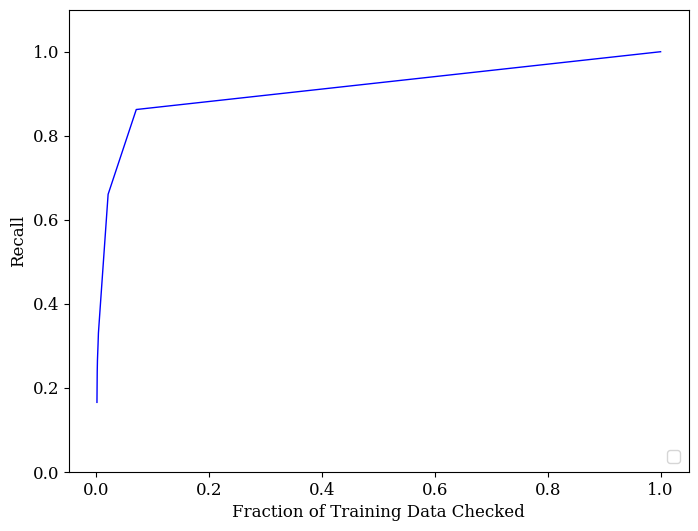

In [73]:
metric = "Recall"

metrics = []

for threshold in range(MAX_SCORE + 1):
    fraction = (scores_df["glare_score"] <= threshold).sum() / len(scores_df)

    y_true = scores_df["mislabeled"]
    y_pred = scores_df["glare_score"].apply(lambda s: 1 if s <= threshold else 0)

    accuracy = accuracy_score(y_true, y_pred)
    recall   = recall_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)

    metrics.append({
        "Fraction": fraction,
        "Accuracy": accuracy,
        "Recall":   recall,
        "F1":       f1
    })

metrics_df = pd.DataFrame(metrics)

metrics_melted = metrics_df.melt(
    id_vars=["Fraction"],
    value_vars=["Accuracy", "Recall", "F1"],
    var_name="Metric",
    value_name="Value"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

df_filtered = metrics_melted[metrics_melted["Metric"] == metric]

plt.figure(figsize=(8, 6))

plt.ylim(0.0, 1.1)

plt.plot(df_filtered["Fraction"], df_filtered["Value"], color="b", linewidth=1)

plt.xlabel("Fraction of Training Data Checked")
plt.ylabel(metric)

plt.legend(frameon=True, loc="lower right")

plt.show()

In [74]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score

# ── Dataset summary ───────────────────────────────────────────────────────────
n_total     = len(scores_df)
n_mislabels = scores_df["mislabeled"].sum()
base_rate   = scores_df["mislabeled"].mean()

# ── Per-threshold metrics ─────────────────────────────────────────────────────
y_true   = scores_df["mislabeled"].values
inverted = MAX_SCORE - scores_df["glare_score"].values  # high = suspicious

auroc = roc_auc_score(y_true, inverted)
ap    = average_precision_score(y_true, inverted)

rows = []
for threshold in range(MAX_SCORE + 1):
    y_pred    = (scores_df["glare_score"] <= threshold).astype(int).values
    fraction  = y_pred.sum() / n_total
    recall    = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    rows.append({"threshold": threshold, "fraction": fraction,
                 "recall": recall, "precision": precision, "f1": f1})

detail_df = pd.DataFrame(rows)
best      = detail_df.loc[detail_df["f1"].idxmax()]

# ── Print ─────────────────────────────────────────────────────────────────────
print("=" * 52)
print("  GLARE Run Summary — VerSe Aug 22, 2026")
print("=" * 52)
print(f"  Training samples:              {n_total:,}")
print(f"  Confirmed mislabels:           {n_mislabels}")
print(f"  Base mislabel rate:            {base_rate:.2%}")
print(f"  Training epochs:               {MAX_SCORE}")
print(f"  GLARE score range:             0 – {MAX_SCORE}")
print()
print("  Detection Performance")
print("  " + "-" * 38)
print(f"  AUROC:                         {auroc:.4f}")
print(f"  Average Precision:             {ap:.4f}")
print(f"  Best F1:                       {best.f1:.4f}  (score ≤ {int(best.threshold)})")
print(f"    Recall at best F1:           {best.recall:.2%}")
print(f"    Precision at best F1:        {best.precision:.2%}")
print(f"    Fraction checked:            {best.fraction:.2%}")
print("=" * 52)
print()
print("  Full threshold table:")
print(detail_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


  GLARE Run Summary — VerSe Aug 22, 2026
  Training samples:              19,266
  Confirmed mislabels:           109
  Base mislabel rate:            0.57%
  Training epochs:               8
  GLARE score range:             0 – 8

  Detection Performance
  --------------------------------------
  AUROC:                         0.9149
  Average Precision:             0.3248
  Best F1:                       0.3956  (score ≤ 4)
    Recall at best F1:           33.03%
    Precision at best F1:        49.32%
    Fraction checked:            0.38%

  Full threshold table:
 threshold  fraction  recall  precision     f1
         0    0.0012  0.1651     0.7826 0.2727
         1    0.0017  0.2385     0.8125 0.3688
         2    0.0021  0.2661     0.7250 0.3893
         3    0.0031  0.3028     0.5500 0.3905
         4    0.0038  0.3303     0.4932 0.3956
         5    0.0071  0.3945     0.3139 0.3496
         6    0.0210  0.6606     0.1782 0.2807
         7    0.0709  0.8624     0.0689 0.1275
   

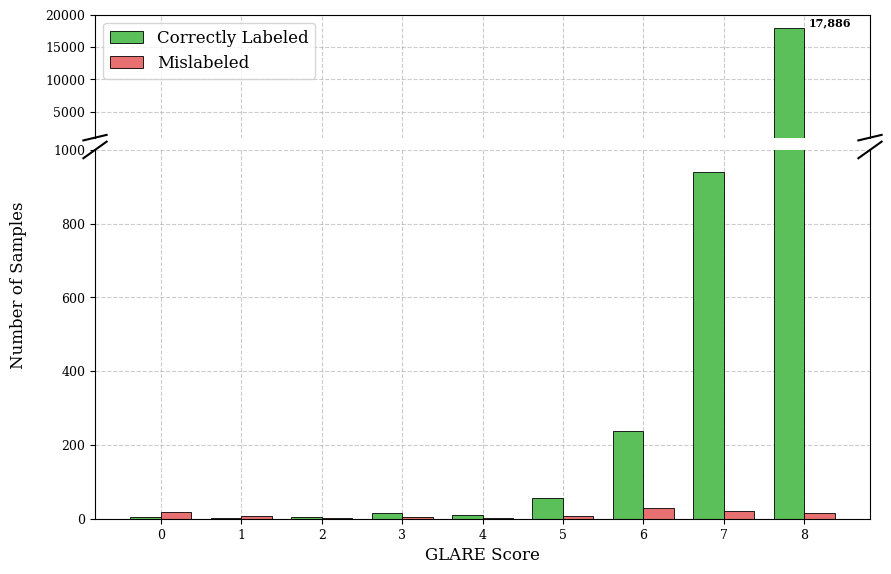

In [75]:
import matplotlib.gridspec as gridspec

score_vals      = list(range(MAX_SCORE + 1))
clean_counts    = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 0)).sum()) for s in score_vals]
mislabel_counts = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 1)).sum()) for s in score_vals]

lower_ylim = 1000
top_ylim   = min(20000, int(np.ceil(max(clean_counts) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim, top_ylim)
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts):
    if c > lower_ylim:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim + (top_ylim - lower_ylim) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}",
                    ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.show()

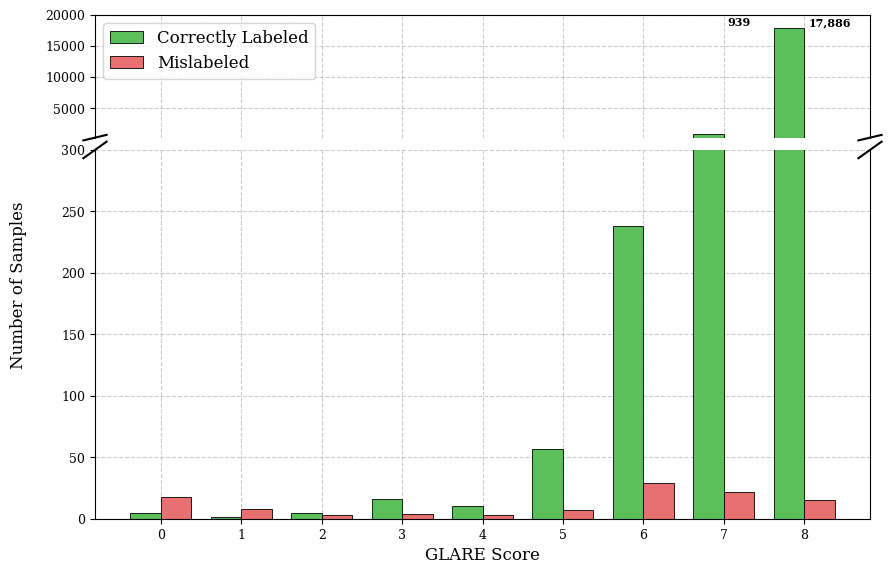

In [76]:
import matplotlib.gridspec as gridspec

score_vals      = list(range(MAX_SCORE + 1))
clean_counts    = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 0)).sum()) for s in score_vals]
mislabel_counts = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 1)).sum()) for s in score_vals]

lower_ylim = 300
top_ylim   = min(20000, int(np.ceil(max(clean_counts) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim, top_ylim)
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts):
    if c > lower_ylim:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim + (top_ylim - lower_ylim) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}",
                    ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.show()

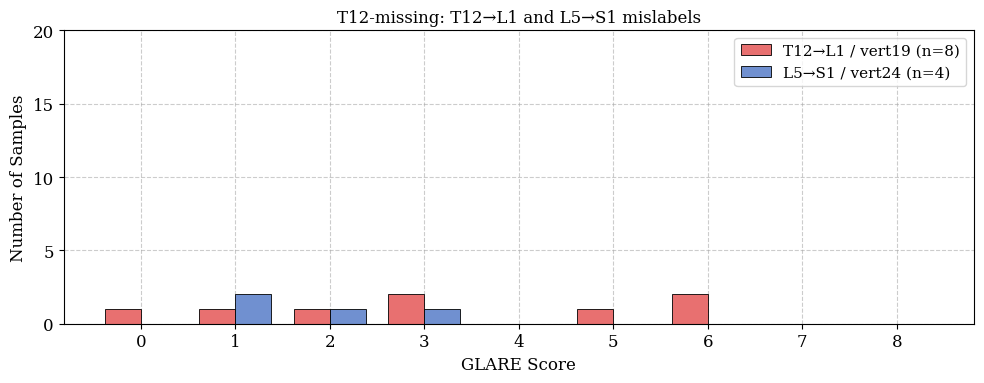

In [77]:
# ── Histogram: T12-missing — T12→L1 (vert19) vs L5→S1 (vert24) ──────────────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df = scores_df[scores_df["id"].isin(v19_ids)]
v24_df = scores_df[scores_df["id"].isin(v24_ids)]

score_vals = list(range(MAX_SCORE + 1))
v19_counts = [int((v19_df["glare_score"] == s).sum()) for s in score_vals]
v24_counts = [int((v24_df["glare_score"] == s).sum()) for s in score_vals]

x     = np.arange(len(score_vals))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v19_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df)})")
ax.bar(x + bar_w/2, v24_counts, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("T12-missing: T12→L1 and L5→S1 mislabels", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T12missing_ep15.pdf", dpi=300, bbox_inches="tight")
plt.show()


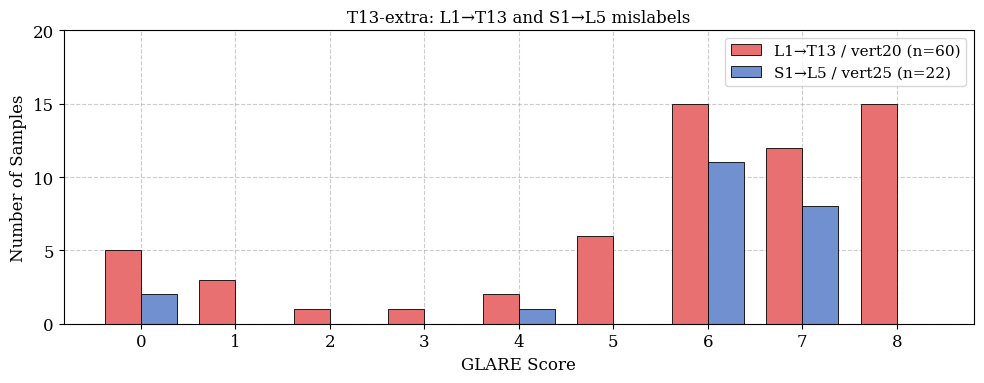

In [78]:
# ── Histogram: T13-extra — L1→T13 (vert20) vs S1→L5 (vert25) ────────────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df = scores_df[scores_df["id"].isin(v20_ids)]
v25_df = scores_df[scores_df["id"].isin(v25_ids)]

score_vals = list(range(MAX_SCORE + 1))
v20_counts = [int((v20_df["glare_score"] == s).sum()) for s in score_vals]
v25_counts = [int((v25_df["glare_score"] == s).sum()) for s in score_vals]

x     = np.arange(len(score_vals))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v20_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df)})")
ax.bar(x + bar_w/2, v25_counts, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("T13-extra: L1→T13 and S1→L5 mislabels", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T13extra_ep15.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [79]:
# ── ep-8 run: load data ───────────────────────────────────────────────────────
MISLABELS_CSV_8 = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
MAX_SCORE_8 = 8

scores_df_8 = pd.read_csv(MISLABELS_CSV_8, dtype=str, keep_default_na=False)
scores_df_8["glare_score"] = pd.to_numeric(scores_df_8["glare score"], errors="coerce")
scores_df_8 = scores_df_8.dropna(subset=["glare_score"]).reset_index(drop=True)
scores_df_8["mislabeled"] = scores_df_8["id"].apply(lambda x: 1 if x in positives else 0)

score_vals_8      = list(range(MAX_SCORE_8 + 1))
clean_counts_8    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals_8]
mislabel_counts_8 = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals_8]

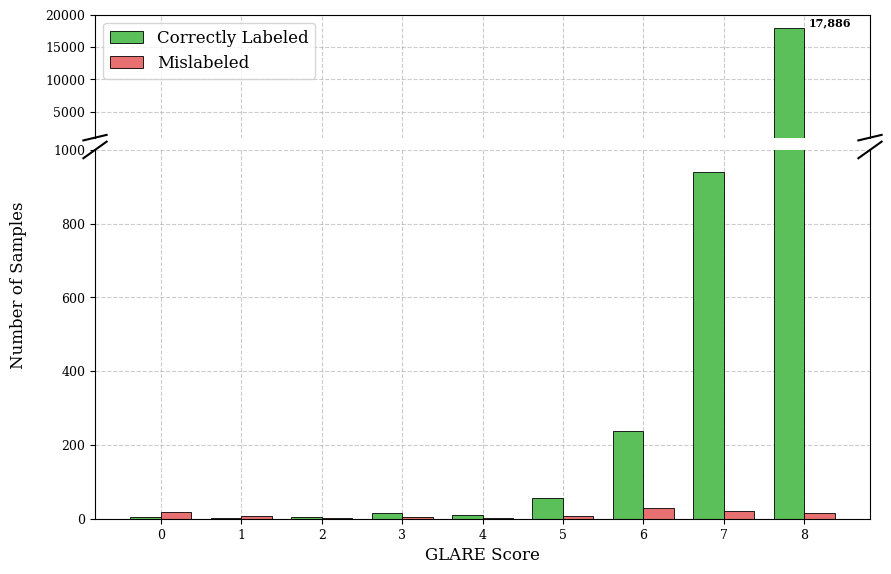

In [80]:
# ── Combined histogram (ep-8, lower_ylim=1000) ───────────────────────────────
lower_ylim_8 = 1000
top_ylim_8   = min(20000, int(np.ceil(max(clean_counts_8) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals_8))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts_8,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim_8, top_ylim_8)
ax_bottom.set_ylim(0, lower_ylim_8)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts_8):
    if c > lower_ylim_8:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim_8 + (top_ylim_8 - lower_ylim_8) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}", ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals_8, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_ep8.jpg", dpi=300, bbox_inches="tight")
plt.show()

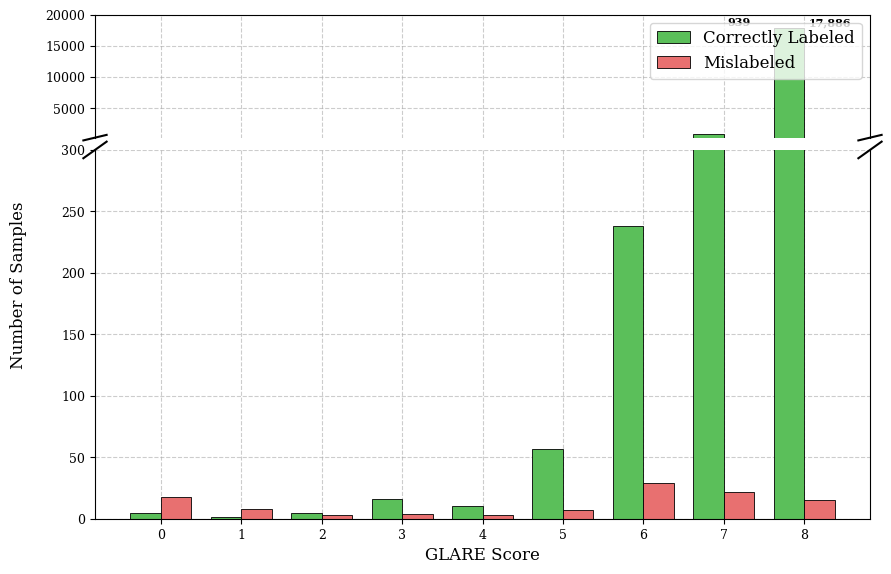

In [81]:
# ── Combined histogram (ep-8, lower_ylim=300) ────────────────────────────────
lower_ylim_8b = 300
top_ylim_8b   = min(20000, int(np.ceil(max(clean_counts_8) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals_8))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts_8,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim_8b, top_ylim_8b)
ax_bottom.set_ylim(0, lower_ylim_8b)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts_8):
    if c > lower_ylim_8b:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim_8b + (top_ylim_8b - lower_ylim_8b) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}", ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals_8, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper right")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_ep8_zoom.jpg", dpi=300, bbox_inches="tight")
plt.show()

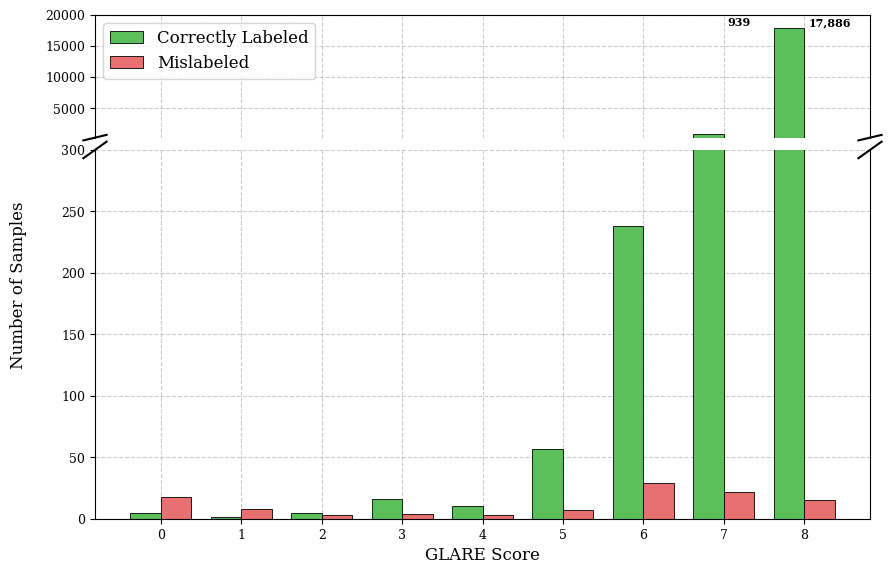

In [82]:
import matplotlib.gridspec as gridspec

score_vals      = list(range(MAX_SCORE_8 + 1))
clean_counts    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals]
mislabel_counts = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals]

lower_ylim = 300
top_ylim   = min(20000, int(np.ceil(max(clean_counts) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim, top_ylim)
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

for i, c in enumerate(clean_counts):
    if c > lower_ylim:
        bar_right = x[i] - bar_w/2 + bar_w/2 + 0.05
        y_pos     = lower_ylim + (top_ylim - lower_ylim) * 0.98
        ax_top.text(bar_right, y_pos, f"{c:,}",
                    ha="left", va="top", fontsize=8, fontweight="bold")

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_ep8_zoom2.jpg", dpi=300, bbox_inches="tight")
plt.show()

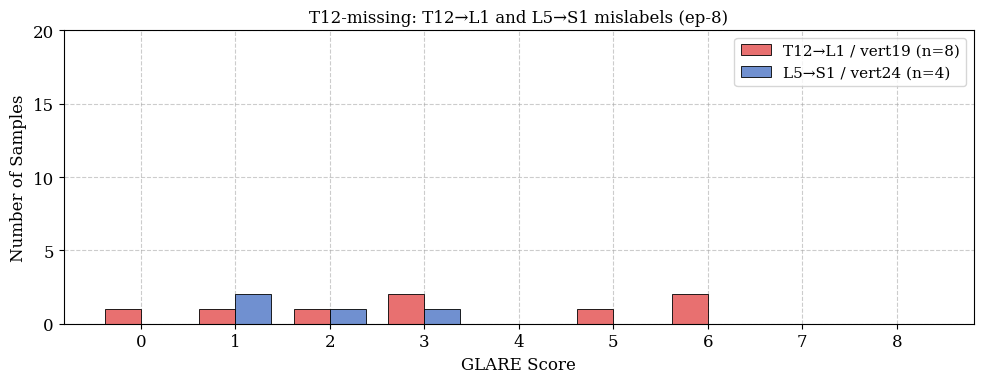

In [83]:
# ── Histogram: T12-missing ep-8 — T12→L1 (vert19) vs L5→S1 (vert24) ─────────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df_8 = scores_df_8[scores_df_8["id"].isin(v19_ids)]
v24_df_8 = scores_df_8[scores_df_8["id"].isin(v24_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v19_counts_8 = [int((v19_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v24_counts_8 = [int((v24_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v19_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df_8)})")
ax.bar(x + bar_w/2, v24_counts_8, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df_8)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("T12-missing: T12→L1 and L5→S1 mislabels (ep-8)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T12missing_ep8.jpg", dpi=300, bbox_inches="tight")
plt.show()

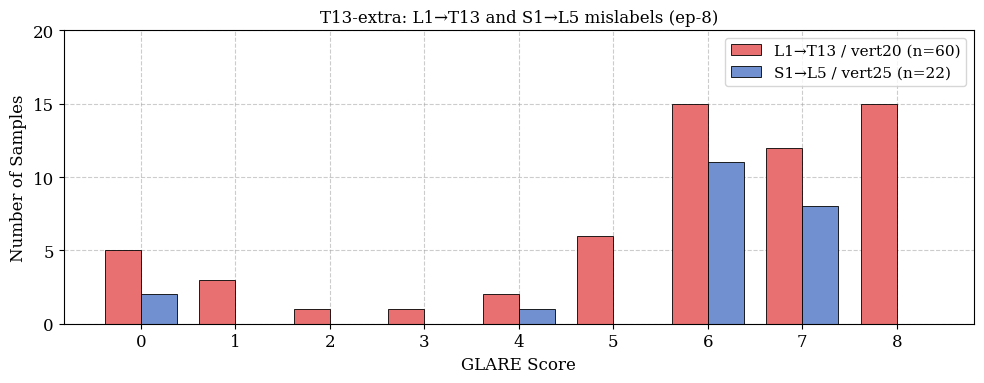

In [84]:
# ── Histogram: T13-extra ep-8 — L1→T13 (vert20) vs S1→L5 (vert25) ───────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df_8 = scores_df_8[scores_df_8["id"].isin(v20_ids)]
v25_df_8 = scores_df_8[scores_df_8["id"].isin(v25_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v20_counts_8 = [int((v20_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v25_counts_8 = [int((v25_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v20_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df_8)})")
ax.bar(x + bar_w/2, v25_counts_8, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df_8)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("T13-extra: L1→T13 and S1→L5 mislabels (ep-8)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_T13extra_ep8.jpg", dpi=300, bbox_inches="tight")
plt.show()

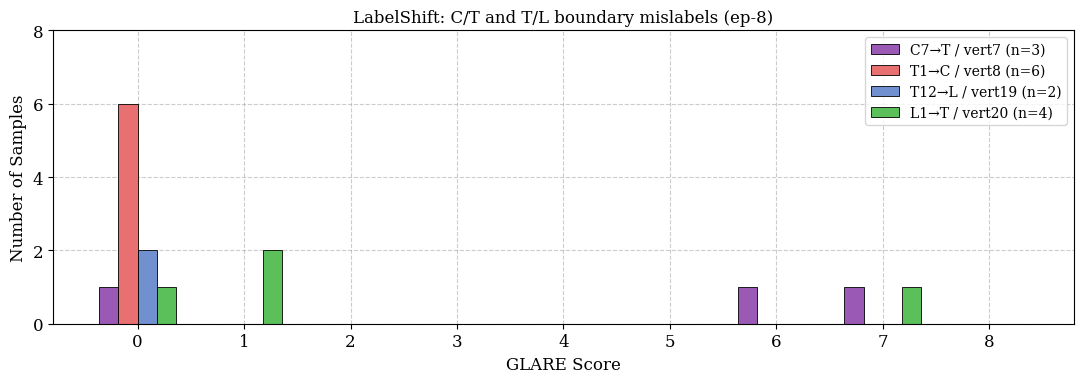

In [85]:
# ── Histogram: LabelShift ep-8 — C/T and T/L boundary mislabels ──────────────
groups = [
    ("label_shift_C_as_T", 7,  "C7→T / vert7",  "#9B59B6"),   # purple
    ("label_shift_T_as_C", 8,  "T1→C / vert8",  "#E87070"),   # red
    ("label_shift_TL",     19, "T12→L / vert19", "#7090D0"),   # blue
    ("label_shift_TL",     20, "L1→T / vert20",  "#5BBF5A"),   # green
]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
x     = np.arange(len(score_vals_8))
n     = len(groups)
bar_w = 0.18
offsets = np.linspace(-(n-1)/2 * bar_w, (n-1)/2 * bar_w, n)

fig, ax = plt.subplots(figsize=(11, 4))

for offset, (atype, vert, label_str, color) in zip(offsets, groups):
    ids = set(df_rc[(df_rc["anomaly_type"] == atype) & (df_rc["vert_id"] == vert)]["sample_id"].astype(str))
    sub = scores_df_8[scores_df_8["id"].isin(ids)]
    counts = [int((sub["glare_score"] == s).sum()) for s in score_vals_8]
    ax.bar(x + offset, counts, width=bar_w, color=color, edgecolor="black",
           linewidth=0.6, label=f"{label_str} (n={len(sub)})")

ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("LabelShift: C/T and T/L boundary mislabels (ep-8)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 8)
ax.set_yticks(range(0, 9, 2))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/histogram_LabelShift_ep8.jpg", dpi=300, bbox_inches="tight")
plt.show()